참고: RNN.pdf
## RNN

- Recurrent Neural NEtwork(RNN) 순환신경망
 > 지금까지의 신경망은 전후 관계를 고려하지 않았음

1. **특정 상태와 상태전이를 학습을 통해서 hidden state 찾음 **
    -  **State(상태), State transition(상태 전이)**, 가중치, bias
    - **연속적**으로 일어나야함
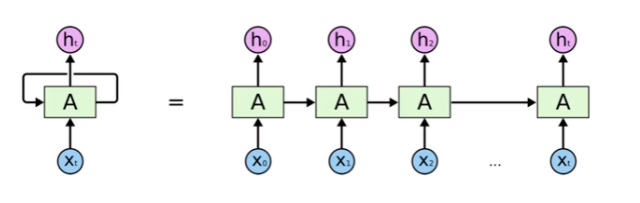
    - 기존의 머신러닝 데이터는 독립적이어야 한다는 가정이 있는데 데이터간의 연관성이 있어도 무관 
      - hidden state: 순서대로 주어지는 관측값을 보고 숨겨진 상태를 학습(추적)
  - 예. 같은 음식이라도 현재 상태가 그동안 많이 먹어서 배가 부른 상태에서는 먹고싶지 않은데 배고픈 상태에서는 더 먹고싶어고 맛있게 느껴짐
  - 현재시점 t 에서의 hidden state: $h_t=tanh(W_{hh} h_{t-1}+W_{xh} x_t)$
  - 현재시점 t 에서의 output: $y_t=W_{hy}h_t$
       - 매 시점에 따라 **상태가 달라서  output이 다름**

2. 활용

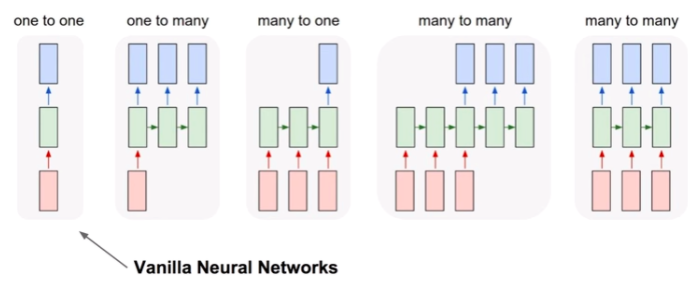
1. 1to1
   - vanilla NN
2. 1 to many
   - Image Captioning 
3. many to 1
   - Sentiment Classifiction
4. many to many( synched/unsynched)
   - Video Classification on frame level 
   - Machine Translation
   
   
학습이 안되는 문제로 활용가치가 떨어졌으나 LSTM 으로 해결

1. CNN
  - locally connected
    - shared weights 
  - Models: LeNet,AlexNet,ZFNet, VGG, GoogLeNet,ResNet
  - 성능 최적화
    - Batch Normalization(BN): 
    - Data Augmentation 
  - Transfer Learning
    - Incremental Learning
      - Catastrophic Forgetting  
      - Knowledge Distillation
        - Light weights model(경량화된 모델)
          - convolution자체를 바꿈 eg. dilated convolution 
 - 활용: object detection, semantic segmentation, locallization

2. RNN : 
  - **순차적** 데이터에 최적 (동영상,자연어,음성에 많이 활용)

## RNN in Keras
- Keras 에서는 직관적이지 못하고 추상적 (과거의 정보를 현재의 정보와 함께 고려하여 예측하여  
일반적인 feed forward 신경망과 다른 구조)
- 다양한 방법을 지원
  - simple RNN     
    - `tf.keras.layers.SimpleRNN(units) 
      - units :출력 갯수
      
units
 - CNN 인간을 뛰어넘는 성공한 모델들을 관례상 따름
 - RNN 구조 상 학습이 잘 안되어 크기를 작게 함

input_shape
- 영상 해석 : 각 행 별로 순서대로 들어감  ( 28x28 : 28개 단어가 28줄로 들어간다) 

In [1]:
import tensorflow as tf

In [2]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data() #hold out

In [3]:
tf.keras.layers.SimpleRNN(units=10)

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.SimpleRNN(units=10,input_shape=(28,28)) # (None,10)
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10)                1560      
                                                                 
Total params: 1,560
Trainable params: 1,560
Non-trainable params: 0
_________________________________________________________________


In [5]:
28*10 + 10*10 + 10  # 390
# X : (N,28,28)
# Wx : (28,10)  
# Wh : (10,10)
# b : 10

390

In [8]:
model(X_train)  # input:(60000,28,28), output: (60000,10)

<tf.Tensor: shape=(60000, 10), dtype=float32, numpy=
array([[ 0.27921012,  0.01980504,  0.13058837, ..., -0.33402768,
         0.1182707 , -0.12088813],
       [-0.2434832 , -0.24840114,  0.21597078, ...,  0.44866025,
        -0.02064484, -0.08761618],
       [ 0.49785078, -0.02108786,  0.14939576, ...,  0.4715185 ,
        -0.02827935,  0.05591157],
       ...,
       [-0.14010331, -0.17442466,  0.08635968, ..., -0.5107155 ,
         0.05720427, -0.02483879],
       [-0.04863232, -0.17737982,  0.07379572, ...,  0.2913571 ,
        -0.20092899, -0.07508396],
       [-0.12374968, -0.25883505,  0.17625305, ...,  0.42946163,
         0.10816206, -0.47423854]], dtype=float32)>

In [14]:
temp = X_train[0][tf.newaxis]  # input: (1,28,28)
model(temp)                    # output (1,10)

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[ 0.27921012,  0.01980492,  0.13058834, -0.2767745 , -0.53257424,
         0.21819887,  0.12277068, -0.33402774,  0.11827075, -0.12088812]],
      dtype=float32)>

In [16]:
import numpy as np
ss = np.resize(temp,(26,28))
ss.shape  # (26,28)
tf.keras.layers.SimpleRNN(units=10,input_shape=(26,28))

### return_sequences
- **활용 목적에 따라가서 모델 구성**을 다르게 해서 RNN 활용
   - 숨겨진 상태,상태전이 찾음
- return_sequences=False
  - many to 1 
- return_sequences=True
  - 1 to many

In [18]:
# return_sequences=True : 결과값 sequences 로 만들어줌 순서적 특징을 뽑아냄
model = tf.keras.models.Sequential([
    tf.keras.layers.SimpleRNN(10,input_shape=(28,28),return_sequences=True) 
])

model(temp)  # (1,28,10)

<tf.Tensor: shape=(1, 28, 10), dtype=float32, numpy=
array([[[ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 1.        , -1.        ,  1.        , -1.        ,
         -1.        ,  1.        , -1.        ,  1.        ,
          1.        , -1.        ],

In [19]:
# return_sequences=False
model= tf.keras.models.Sequential([
      tf.keras.layers.SimpleRNN(10, input_shape=( 28,28 ),return_sequences=False )   # many to one   (Flatten 해도 상관 없음)                   
])
model(temp).shape      # 마지막에 최종적 10개 결과

TensorShape([1, 10])

In [20]:
# return_sequences=False
model= tf.keras.models.Sequential([
      tf.keras.layers.SimpleRNN(10, input_shape=( 28,28 ),return_sequences=False , activation='tanh') ,
      #tf.keras.layers.Flatten(), #차이가 없음 
      tf.keras.layers.Dense(10,activation='softmax')                    
])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_6 (SimpleRNN)    (None, 10)                390       
                                                                 
 dense (Dense)               (None, 10)                110       
                                                                 
Total params: 500
Trainable params: 500
Non-trainable params: 0
_________________________________________________________________


In [21]:
# return_sequences=True
model= tf.keras.models.Sequential([
      tf.keras.layers.SimpleRNN(10, input_shape=( 28,28 ),return_sequences=True , activation='tanh') ,
      tf.keras.layers.Dense(10,activation='softmax')                    
])
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_7 (SimpleRNN)    (None, 28, 10)            390       
                                                                 
 dense_1 (Dense)             (None, 28, 10)            110       
                                                                 
Total params: 500
Trainable params: 500
Non-trainable params: 0
_________________________________________________________________


In [22]:
# return_sequences=True,  Flatten :  28x10을 1열로 바꾸어버림 -> 28x10=280
model= tf.keras.models.Sequential([
      tf.keras.layers.SimpleRNN(10, input_shape=( 28,28 ),return_sequences=True , activation='relu') ,
      tf.keras.layers.Flatten(), 
      tf.keras.layers.Dense(10,activation='softmax')                    
])
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_8 (SimpleRNN)    (None, 28, 10)            390       
                                                                 
 flatten (Flatten)           (None, 280)               0         
                                                                 
 dense_2 (Dense)             (None, 10)                2810      
                                                                 
Total params: 3,200
Trainable params: 3,200
Non-trainable params: 0
_________________________________________________________________


In [23]:
#성능 좋은지 확인용 :parameters가 많으면 성능이 좋음  
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.fit(X_train,y_train, epochs=10)   # CPU 약 2.5분 

Epoch 1/10
1875/1875 [==============================] - 16s 8ms/step - loss: 7.5345 - acc: 0.7442
Epoch 2/10
1875/1875 [==============================] - 15s 8ms/step - loss: 0.8207 - acc: 0.8466
Epoch 3/10
1875/1875 [==============================] - 15s 8ms/step - loss: 0.3782 - acc: 0.8973
Epoch 4/10
1875/1875 [==============================] - 14s 8ms/step - loss: 0.2699 - acc: 0.9215
Epoch 5/10
1875/1875 [==============================] - 13s 7ms/step - loss: 0.2385 - acc: 0.9309
Epoch 6/10
1875/1875 [==============================] - 12s 7ms/step - loss: 0.2240 - acc: 0.9350
Epoch 7/10
1875/1875 [==============================] - 16s 8ms/step - loss: 0.2097 - acc: 0.9383
Epoch 8/10
1875/1875 [==============================] - 16s 9ms/step - loss: 0.2017 - acc: 0.9401
Epoch 9/10
1875/1875 [==============================] - 15s 8ms/step - loss: 0.1938 - acc: 0.9423
Epoch 10/10
1875/1875 [==============================] - 16s 8ms/step - loss: 0.1888 - acc: 0.9443


In [24]:
 # return_sequences = true
model.evaluate(X_test, y_test)  #정확도 93.5%

313/313 [==============================] - 2s 4ms/step - loss: 0.1959 - acc: 0.9469


[0.19585976004600525, 0.9469000101089478]

In [27]:
#parameters 500개로 성능이 좋지 않음
model= tf.keras.models.Sequential([
      tf.keras.layers.SimpleRNN(10, input_shape=( 28,28 ),return_sequences=False , activation='relu') ,
      tf.keras.layers.Dense(10,activation='softmax')                    
])
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_10 (SimpleRNN)   (None, 10)                390       
                                                                 
 dense_4 (Dense)             (None, 10)                110       
                                                                 
Total params: 500
Trainable params: 500
Non-trainable params: 0
_________________________________________________________________


In [28]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.fit(X_train,y_train, epochs=10)    # CPU 약 2.2분 

Epoch 1/10
1875/1875 [==============================] - 14s 7ms/step - loss: 2.9894 - acc: 0.2199
Epoch 2/10
1875/1875 [==============================] - 13s 7ms/step - loss: 1.8531 - acc: 0.3415
Epoch 3/10
1875/1875 [==============================] - 13s 7ms/step - loss: 1.7286 - acc: 0.3627
Epoch 4/10
1875/1875 [==============================] - 11s 6ms/step - loss: 1.6371 - acc: 0.4003
Epoch 5/10
1875/1875 [==============================] - 13s 7ms/step - loss: 1.4674 - acc: 0.4514
Epoch 6/10
1875/1875 [==============================] - 16s 8ms/step - loss: 1.3554 - acc: 0.4841
Epoch 7/10
1875/1875 [==============================] - 14s 8ms/step - loss: 1.3119 - acc: 0.4931
Epoch 8/10
1875/1875 [==============================] - 17s 9ms/step - loss: 1.2866 - acc: 0.5047
Epoch 9/10
1875/1875 [==============================] - 22s 12ms/step - loss: 1.2618 - acc: 0.5148
Epoch 10/10
1875/1875 [==============================] - 21s 11ms/step - loss: 1.2390 - acc: 0.5223


In [29]:
 #return_sequences=False 
model.evaluate(X_test, y_test)  #정확도 53.0%

313/313 [==============================] - 1s 3ms/step - loss: 1.2350 - acc: 0.5283


[1.235032558441162, 0.5282999873161316]

> - `tf.keras.layers.RNN`
    - cell instance 한 개
    - 고급기법에 사용

### return_state
- 맨 마지막 레이어에 state 변활할지 안할지 결정
- `return_state=True` 
  - Functional API:  Model

In [35]:
# return_state=True 
inp = tf.keras.Input((28,28))
rnn = tf.keras.layers.SimpleRNN(10,return_state=True)(inp)
model = tf.keras.models.Model(inputs=inp,outputs=rnn)

In [36]:
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 simple_rnn_14 (SimpleRNN)   [(None, 10),              390       
                              (None, 10)]                        
                                                                 
Total params: 390
Trainable params: 390
Non-trainable params: 0
_________________________________________________________________


### TimeDistributed
- many to many 구조: 각각의 dense layer를 wrapper 방식으로  감쌈 
- layer wrapper
- input 을 최소 3차원의 layer를 받음 
- `keras.layers.TimeDistributed(layer)`

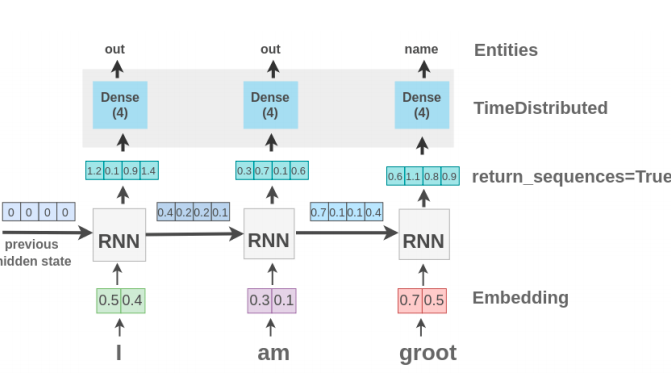

https://m.blog.naver.com/PostView.naver?isHttpsRedirect=true&blogId=chunjein&logNo=221589624838

In [65]:
#  Conv2D를 감싼 경우 예제
inputs = tf.keras.Input(shape=(10, 128, 128, 3))
conv_2d_layer = tf.keras.layers.Conv2D(64, (3, 3))
outputs = tf.keras.layers.TimeDistributed(conv_2d_layer)(inputs)
outputs.shape

TensorShape([None, 10, 126, 126, 64])

In [37]:
# TimeDistributed 3차원 받음 : return_sequences=True : TensorShape([1, 10])  -> TensorShape([1, 28, 10]) 
layer1 = tf.keras.layers.SimpleRNN(10, input_shape=(28,28),return_sequences=True)

# TimeDistributed: Dense 분배
dense = tf.keras.layers.Dense(10)
layer2 = tf.keras.layers.TimeDistributed(dense)

In [38]:
model = tf.keras.models.Sequential([
    layer1,
    layer2
])

In [39]:
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_15 (SimpleRNN)   (None, 28, 10)            390       
                                                                 
 time_distributed (TimeDistr  (None, 28, 10)           110       
 ibuted)                                                         
                                                                 
Total params: 500
Trainable params: 500
Non-trainable params: 0
_________________________________________________________________


In [42]:
#위와 비교 했을때는 차이가 없음 time distributed 표기 외에 
model= tf.keras.models.Sequential([
      tf.keras.layers.SimpleRNN(10, input_shape=( 28,28 ),return_sequences=True , activation='tanh') ,
      #tf.keras.layers.Flatten(),  
      tf.keras.layers.Dense(10,activation='softmax')                    
])
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_18 (SimpleRNN)   (None, 28, 10)            390       
                                                                 
 dense_8 (Dense)             (None, 28, 10)            110       
                                                                 
Total params: 500
Trainable params: 500
Non-trainable params: 0
_________________________________________________________________


In [43]:
model= tf.keras.models.Sequential()
model.add(tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(8),
                                          input_shape=(10,16)))
model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_1 (TimeDis  (None, 10, 8)            136       
 tributed)                                                       
                                                                 
Total params: 136
Trainable params: 136
Non-trainable params: 0
_________________________________________________________________


### Long term dependency 
- 단기 기억은 잘 되나 점점 길어질수록 학습이 잘 안됨
   
   - Gradient Vanishing 문제 
    1. 활성 함수 sigmoid, tanh 사용대신에 `relu`  
      - sigmoid, tanh : 깊을수록 미분값이 0에 가까워지면서 0이 계속 전달되면서 학습이 잘 안됨 
    2. 초기값 initalizer
 
   - gradient exploding 문제
        - 학습하면서 값들이 커짐
    1. 아주 작은 초기값
    2. gradient clipping 일정 이상 값을 잘름

In [44]:
x=tf.Variable(tf.range(-8., 8, .1))
with tf.GradientTape(persistent=True) as t:
     y=tf.nn.sigmoid(x)

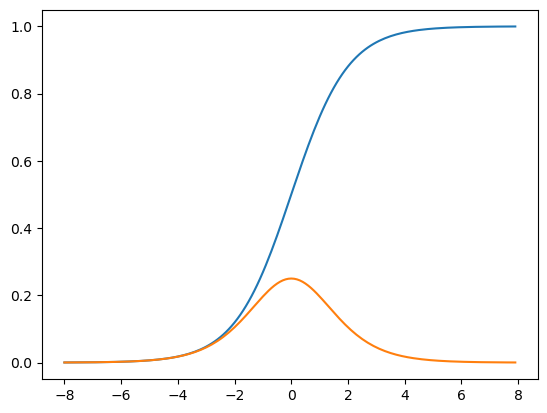

In [47]:
import matplotlib.pyplot as plt

plt.plot(x.numpy(),y.numpy()) #sigmoid
plt.plot(x.numpy(),t.gradient(y,x).numpy() )#미분한 sigmoid  끝에는 0에 가까워서 gradient vanishing

In [59]:
x=tf.random.normal((4,4))
x

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[-0.65155965,  2.245661  , -1.2382362 , -0.14260973],
       [ 0.7750188 ,  0.5748705 ,  0.5736289 , -0.1815305 ],
       [-1.1511443 ,  3.0474916 ,  0.9812773 ,  0.33955392],
       [-1.5618546 ,  1.9835654 , -0.6317016 , -0.02313188]],
      dtype=float32)>

In [60]:
#gradient update 1000번 랜덤한값 곱함
for i in range(1000):
    x = tf.matmul(x, tf.random.normal((4,4)))

In [61]:
x

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan]], dtype=float32)>

In [62]:
# tf.keras.layers.ConvLSTM2D #비디오 영상처리에 사용하는 기법 

In [63]:
model=tf.keras.models.Sequential([
                                  tf.keras.layers.SimpleRNN(10,return_sequences=True
                                                            , input_shape=(28,28)),
                                  tf.keras.layers.SimpleRNN(10,return_sequences=True),
])

In [64]:
model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_19 (SimpleRNN)   (None, 28, 10)            390       
                                                                 
 simple_rnn_20 (SimpleRNN)   (None, 28, 10)            210       
                                                                 
Total params: 600
Trainable params: 600
Non-trainable params: 0
_________________________________________________________________


#### LSTM
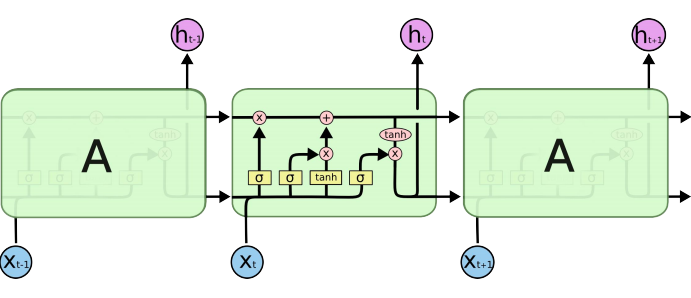

- Long Short-Term Memory
- '구조 자체를 변경'해서 인간의 사고 구조를 흉내내어 문제점을 해결
 - 현재 시점으로 부터 오래될수록 학습 문제를 해결하는 방법
1. **cell state 셀 상태 기억을 유지**하도록 컨베이어 벨트처럼 만듦(기억 저장)
2. 3개의 cell gates: 셀상태 유지하는 정도를 관리함
  - forget gate 기억
  - input gate  입력
      - 기억을 할지 안할지 결정
  - output gate 출력
- 연산이 복잡하고 성능 더 좋은 것들이 많고 더 복잡한게 많음